<a href="https://colab.research.google.com/github/Modhu54/Chemical-Engineering-Problems/blob/main/PI_control_CSTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
from math import *
import matplotlib.pyplot as plt
import numpy as np

Major governing equation of PI control in CSTR reactor to control Jacket temperature

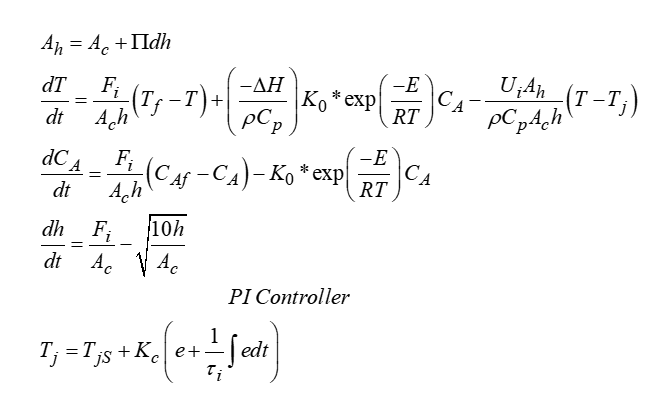

Initialization of Model Parameters :

In [ ]:
d=2.335              # Diameter of the reactor
AC=4.2822            # Cross sectional area
Caf=10.0             # Concentration of reactant A in the feed stream
Me=0.14              # Ui/(RowCp)
Y=5960.24157         # Y = E/R
dt=0.005             # time width
Z=34930800           # Frequency factor
X=416375136          # X = (-HZ)/(Row*Cp)
f=1387917120         # f = (–H*V*Z)/(Ui*Ah)



In [ ]:

T0 = 38.17771         # Initial reactor temperature
Ca0 = 8.56303         # Initial concentration of A in the feed
h0 = 2.335201         # Initial liquid height

kc = 100              #
ki = 5


t =0
Tj0 = 25                   # Initial Jacket temperature
Fi = 10                    # Feed flow rate
Tf = 25                    # Feed temperature

integral = 0

T_pts= []
Ca_pts = []
h_pts = []
t_pts = []
Tj_pts = []
Tsp_pts = []

while t<60:
  #setting condition for Set temperature
  if t<=5:
    Tsp1 = 38.2
  if t>5 and t<=30:
    Tsp1 = 66.1
  if t>30 and t<=40:
    Tsp1 = 95.1
  if t>40 and t<=60:
    Tsp1 =66.1

    # same ODE of
  #AH - > Heat transfer area, m2
  #T - > Reactor temperature, K
  #Ca - >concentration of reactant A in the exit stream, kmol/m3
  #h - > height of the reactor liquid, m

  AH=AC+3.14159*d*h0
  T=T0+dt*((X*Ca0*exp(-Y/(273.0+T0)))-(((Me*AH)/(AC*h0))*(T0-Tj0))+((Tf-T0)*(Fi/(AC*h0))))
  Ca=Ca0+dt*(((Fi/(AC*h0))*(Caf-Ca0))-(Z*Ca0*exp(-Y/(273.0+T0))))
  h=h0+dt*((Fi/AC)-(pow((10.0*h0/AC),0.5)))

  #Application of Proportional integral controller
  e = Tsp1 - T
  integral += e*dt

  Tj = 25 + kc*e + ki*integral

  if Tj>=65:
    Tj=65
  if Tj<=15:
    Tj=15


  T_pts.append(T)
  Ca_pts.append(Ca)
  h_pts.append(h)
  t_pts.append(t)
  Tj_pts.append(Tj)
  Tsp_pts.append(Tsp1)

  t +=dt
  T0 = T
  Ca0 = Ca
  h0 = h
  Tj0 = Tj



Servo performance of the PI control algorithm

Reactor temperature control

([<matplotlib.axis.XTick at 0x7aba1cc1ac50>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60')])

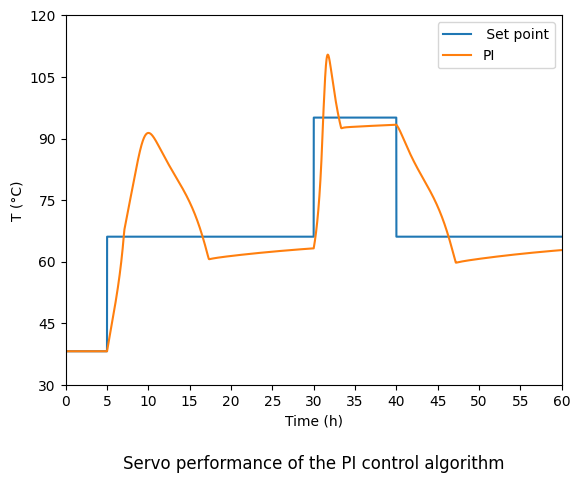

In [ ]:

plt.plot(t_pts,Tsp_pts, label =' Set point')
plt.plot(t_pts,T_pts,label ='PI')
plt.legend()

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Servo performance of the PI control algorithm", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel("T (°C)")
plt.ylim([30,120])
plt.xlim([0,60])
plt.yticks(np.arange(30,121, 15))
plt.xticks(np.arange(0, 61, 5))

Variation in the Jacket temperature

([<matplotlib.axis.XTick at 0x7aba1c1683a0>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60')])

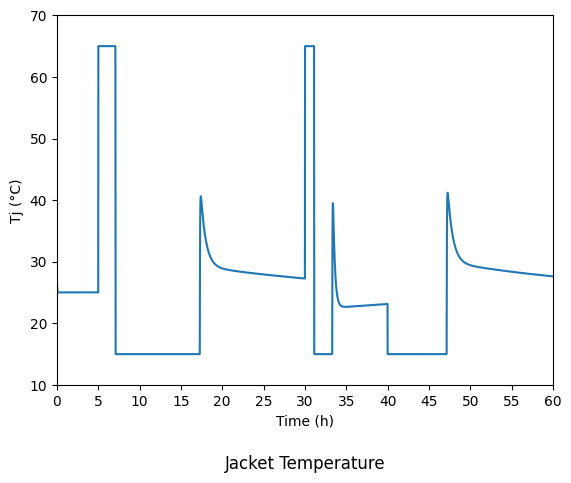

In [ ]:
plt.plot(t_pts,Tj_pts)

plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Jacket Temperature", y=-0.25)
plt.xlabel('Time (h)')
plt.ylabel("Tj (°C)")
plt.ylim([10,70])
plt.xlim([0,60])
plt.yticks(np.arange(10,71, 10))
plt.xticks(np.arange(0, 61, 5))